## Pipeline dựa trên eda mới


In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import os
import warnings
import seaborn as sns
from sklearn.linear_model import LogisticRegression
warnings.filterwarnings('ignore')

In [2]:
for dirname, _, filenames in os.walk("Dataset"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Dataset\sample_submission.csv
Dataset\test_identity.csv
Dataset\test_transaction.csv
Dataset\train_identity.csv
Dataset\train_transaction.csv


In [3]:
train_identity = pd.read_csv("Dataset/train_identity.csv")
train_transaction = pd.read_csv("Dataset/train_transaction.csv")

print(f"train_identity.shape= {train_identity.shape}")
print(f"train_transaction.shape= {train_transaction.shape}")

train_identity.shape= (144233, 41)
train_transaction.shape= (590540, 394)


In [4]:
train = train_transaction.merge(train_identity, how="left", on="TransactionID")
train.head(5)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [5]:
print(f"Train Transation Shape: {train_transaction.shape} | Train Identity Shape: {train_identity.shape} | Merged train shape: {train.shape}")

Train Transation Shape: (590540, 394) | Train Identity Shape: (144233, 41) | Merged train shape: (590540, 434)


In [6]:
# selected feature: thu thập các feature trích xuất
selected_feature = []

- Biến transactionDT đã được khám phá là thời gian trôi qua kể từ một mốc nào đó và được tính bằng giây
- Theo phân tích tỉ lệ Fraud tăng đột biến ở 1 vài khung giờ cố định trong ngày hơn là số ngày trong tuần nên ta giữ lại đặc trưng `Hours`
- Đặc trưng D9 cũng là `Hour of Day`, nhưng đặc trưng này có quá nhiều giá trị missing và trùng ý nghĩa với cột `Hours` được trích từ TransactionDT nên ta sẽ drop cột `D9`

In [7]:
train['Hour'] = np.floor((train['TransactionDT'] / 3600) % 24)

selected_feature.append('Hour')

- Biến ProductCD cho thấy tỉ lệ giao dịch Fraud chiếm phần lớn ở các mã sản phẩm ít được giao dịch
- Tỉ lệ giao dịch gian lận cũng liên quan đến phân phối thống kê của số tiền giao dịch với các sản phẩm, cụ thể: các nhóm sản phẩm W, R, và H có số tiền được thực hiện ở các giao dịch lừa đảo cao hơn bình thường. Trong khi với nhóm S và C thì lại có tỉ lệ gần bằng

In [8]:
temp_mean = train.groupby('ProductCD')['TransactionAmt'].transform('mean')
temp_std = train.groupby('ProductCD')['TransactionAmt'].transform('std')

# Đánh dấu nguy cơ của các giao dịch theo loại sản phẩm Low - Medium
map_productCD_to_risk = {
    "C": "High",
    "R": "Medium",
    "S": "Medium",
    "H": "Medium",
    "W": "Low"
}
train['ProductCD_Risk'] = train['ProductCD'].map(map_productCD_to_risk)

# Tỷ lệ giữa số tiền giao dịch và mức trung bình của nhóm
train['Amt_to_Mean_ProductCD'] = train['TransactionAmt'] / temp_mean

# Số tiền này cách mức trung bình bao nhiêu lần độ lệch chuẩn?
train['Amt_to_Std_ProductCD'] = (train['TransactionAmt'] - temp_mean) / temp_std

selected_feature.extend(['ProductCD_Risk', 'Amt_to_Mean_ProductCD', 'Amt_to_Std_ProductCD'])

- Tại giá trị của các card1, card2, card3 và card5: có một sự biến động bất thường của các giá trị cụ thể.
- Tỉ lệ gian lận là khá thấp đối với các giá trị phổ biến và ngược lại

In [9]:
# frequent encoding do tỉ lệ gian lận liên quan đến độ phổ biến
card_cols = ['card1', 'card2', 'card3', 'card5']
for col in card_cols:
    fraud_rate_by_col = train.groupby(col)['isFraud'].mean()
    mean_fraud_rate_by_col = fraud_rate_by_col.mean()
    std_fraud_rate_by_col = fraud_rate_by_col.std()

    def risk_level(x):
        if x > mean_fraud_rate_by_col + 2 * std_fraud_rate_by_col:
            return 'high'
        elif x > mean_fraud_rate_by_col + std_fraud_rate_by_col:
            return 'medium'
        else:
            return 'low'
        
    map_risk = fraud_rate_by_col.apply(risk_level)
    train[f'{col}_risk'] = train[col].map(map_risk)

    freq_encoding = train[col].fillna(-999).value_counts().to_dict()
    train[f'{col}_freq'] = train[col].fillna(-999).map(freq_encoding)
    selected_feature.extend([f'{col}_risk', f'{col}_freq'])


- Thẻ card4 có số lượng giao dịch bất thường khá lớn đối với thẻ discover, và lượng tiền được thực hiện trong các giao dịch lừa đảo với loại thẻ này cũng rất lớn.
- -> thêm feature chên lệch số tiền giao dịch hiện tại so với trung bình giao dịch của nhóm thẻ card4

In [10]:
train['card4_Amt_mean'] = train.groupby('card4')['TransactionAmt'].transform("mean")
train['card4_Amt_diff'] = train['TransactionAmt'] - train['card4_Amt_mean']


selected_feature.extend(['card4_Amt_mean', 'card4_Amt_diff'])


- Cột `card6` **Credit** có số lượng giao dịch gian lận lớn hơn hẳn các cột khác -> chuyển cột này thành dữ liệu rời rạc ghi nhận alert

In [11]:
# card6 có điểm alert đáng chú ý ở credit nhưng thông tin về số tiền giao dịch không có nhiều giá trị
train['card6_Credit'] = (train['card6'] == "credit").astype(int)
selected_feature.append('card6_Credit')

- Biến `addr1` có tỉ lệ gian lận cao hơn missing value
- Biến `addr2` có giá trị 65 chiếm tỉ lệ fraud lên tới 55% mặc dù giá trị giao dịch không quá lớn

In [12]:
freq_map = train['addr2'].value_counts(normalize=True)
train['addr2_freq'] = train['addr2'].map(freq_map)

freq_map = train['addr1'].value_counts(normalize=True)
train['addr1_freq'] = train['addr1'].map(freq_map)

# Ta thêm cả biến addr1 vì giá trị null của nó có liên quan đến gian lận
selected_feature.extend(['addr1', 'addr2', 'addr2_freq', 'addr1_freq'])

- Một số domain email có tỉ lệ gian lận cao. Đáng chủ ý là missing data cchieems gần 80& nhưng tỉ lệ gian lận thấp -> ta nên ánh xạ các các domain thành Risk Binning: Low - Medium - High Risk

In [13]:
high_risk_emails = ['protonmail.com', 'mail.com']
medium_risk_emails = ['gmail.com', 'yahoo.com', 'hotmail.com']

def map_email_risk(email):
    if pd.isna(email):
        return 'Low' # 80% null có tỷ lệ gian lận thấp
    elif email in high_risk_emails:
        return 'High'
    elif email in medium_risk_emails:
        return 'Medium'
    else:
        return 'Low'
        
train['Email_Risk_Bin'] = train['P_emaildomain'].apply(map_email_risk)
selected_feature.append('Email_Risk_Bin')

In [14]:
freq_map = train['P_emaildomain'].value_counts(normalize=True)
train['P_email_freq'] = train['P_emaildomain'].map(freq_map)
selected_feature.append('P_email_freq')

In [15]:
freq_map = train['R_emaildomain'].value_counts(normalize=True)
train['R_email_freq'] = train['R_emaildomain'].map(freq_map)
selected_feature.append('R_email_freq')

In [16]:
# Mã hóa card_id
card_cols = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6']
train['card_id'] = train[card_cols].astype(str).agg('_'.join, axis=1)

# Mã hóa addr_id
addr_cols = ['addr1', 'addr2']
train['addr_id'] = train[addr_cols].astype(str).agg('_'.join, axis=1)


uid_cols = ['card_id',  'addr_id']
train['uid'] = train[uid_cols].fillna('Missing').astype(str).agg('_'.join, axis=1)


print(f"Số lượng uid duy nhất: {train['uid'].nunique()}")

Số lượng uid duy nhất: 43071


In [17]:
# Tính số tiền trung bình và độ lệch chuẩn của mỗi UID
train['TransactionAmt_mean_uid'] = train.groupby('uid')['TransactionAmt'].transform('mean')
train['TransactionAmt_std_uid'] = train.groupby('uid')['TransactionAmt'].transform('std')

# Tính độ lệch giữa giao dịch hiện tại và trung bình của UID đó
train['TransactionAmt_diff_uid'] = train['TransactionAmt'] - train['TransactionAmt_mean_uid']

# Đếm số lượng giao dịch của UID này (Frequency Encoding cho UID)
train['uid_count'] = train.groupby('uid')['TransactionID'].transform('count')
selected_feature.extend(['TransactionAmt_diff_uid', 'uid_count'])

- giá trị giao dịch của `DeviceType` Mobile là thấp nhất nhưng tỉ lệ gian lận là cao nhất (> 10%)

In [18]:
def map_device_type_risk(type):
    if pd.isna(type):
        return 'Low'
    elif type == "desktop":
        return 'Medium'
    elif type == "mobile":
        return 'High'
    
train['Device_type_risk'] = train['DeviceType'].apply(map_device_type_risk)
selected_feature.append('Device_type_risk')


- Đối với `DeviceInfo`, các dòng máy Android đời cũ (SM-Gxxx...) có tỷ lệ gian lận cao. đặc biệt là rv::11 thường nhắm vào các khoản tiền lớn

- Có thể tạo biến: TransactionAmt / Mean_Amount_by_Device. Nếu một thiết bị ít xuất hiện nhưng thực hiện giao dịch lớn bất thường thì đó là dấu hiệu gian lận.

In [19]:
# TransactionAmt / Mean_Amount_by_Device
train['Device_Amt_Mean'] = train.groupby('DeviceInfo')['TransactionAmt'].transform('mean')
train['Amt_to_Device_Mean_Ratio'] = train['TransactionAmt'] / train['Device_Amt_Mean']

# Flag các dòng máy rủi ro
train['is_old_android'] = train['DeviceInfo'].str.contains('SM-G', na=False, case=False).astype(int)
train['is_rv11'] = train['DeviceInfo'].str.contains('rv:11', na=False, case=False).astype(int)
selected_feature.extend(['Amt_to_Device_Mean_Ratio', 'is_old_android', 'is_rv11'])


- Chú ý một vài feature `id` (ví dụ 13, 14, 18, 21, 22, 24) có một số phân loại có Fraud Rate đỉnh nóc. Có thể chú ý các giá trị và tạo thêm feature High Risk.... ? 

In [20]:
id_cols = ['id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_24']

for col in id_cols:
    freq_map = train[col].value_counts(normalize=True)
    train[f'{col}_freq'] = train[col].map(freq_map)
    selected_feature.append(f'{col}_freq')


In [21]:
print(f"Danh sách các categorical feature trích xuất được: {selected_feature}")
print(f"Số các categorical feature trích xuất được: {len(selected_feature)}")

Danh sách các categorical feature trích xuất được: ['Hour', 'ProductCD_Risk', 'Amt_to_Mean_ProductCD', 'Amt_to_Std_ProductCD', 'card1_risk', 'card1_freq', 'card2_risk', 'card2_freq', 'card3_risk', 'card3_freq', 'card5_risk', 'card5_freq', 'card4_Amt_mean', 'card4_Amt_diff', 'card6_Credit', 'addr1', 'addr2', 'addr2_freq', 'addr1_freq', 'Email_Risk_Bin', 'P_email_freq', 'R_email_freq', 'TransactionAmt_diff_uid', 'uid_count', 'Device_type_risk', 'Amt_to_Device_Mean_Ratio', 'is_old_android', 'is_rv11', 'id_12_freq', 'id_13_freq', 'id_14_freq', 'id_15_freq', 'id_16_freq', 'id_18_freq', 'id_19_freq', 'id_20_freq', 'id_21_freq', 'id_22_freq', 'id_24_freq']
Số các categorical feature trích xuất được: 39


- Ta thêm một số phép encode có liên quan để tăng đặc trưng nhận diện cho model

## Tiếp tục xử lý num feature

In [22]:
num_feature = []
for col in train.columns:
    if (train[col].dtype != "object") and (col not in selected_feature):
        num_feature.append(col)
print(f"Danh sách các num feature trong tập train: {num_feature}")
print(f"Tổng số các num feature trong tập train: {len(num_feature)}")

Danh sách các num feature trong tập train: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95'

In [23]:
# handle missing values of numerical features
num_features_to_be_dropped = []
for feature in num_feature:
    if train[feature].isnull().mean() > 0.6:
        num_features_to_be_dropped.append(feature)
    elif feature != "isFraud":
        train[feature].fillna(train[feature].median(), inplace=True)

In [24]:
num_left = list(set(num_feature) - set(num_features_to_be_dropped))
print(f"num_left= {num_left}")
print(f"len of num_left= {len(num_left)}")

num_left= ['V118', 'V283', 'V117', 'V71', 'V314', 'V87', 'C5', 'V281', 'V100', 'V131', 'V24', 'V96', 'C9', 'V52', 'V125', 'V51', 'V98', 'V303', 'V127', 'V2', 'V133', 'V90', 'V301', 'V109', 'V18', 'V6', 'TransactionAmt', 'V130', 'V32', 'V44', 'V13', 'V33', 'V65', 'C13', 'V83', 'V305', 'V97', 'V31', 'V84', 'V74', 'V35', 'V67', 'V293', 'V285', 'V89', 'V122', 'V23', 'V19', 'V132', 'card5', 'V321', 'V64', 'V48', 'V302', 'card3', 'isFraud', 'V30', 'V3', 'V85', 'V79', 'V110', 'V37', 'D5', 'V282', 'V36', 'V307', 'V309', 'V103', 'V312', 'V134', 'C6', 'V292', 'V72', 'V70', 'V129', 'V316', 'V80', 'C11', 'V287', 'V57', 'V295', 'V299', 'V16', 'V280', 'dist1', 'V126', 'TransactionAmt_std_uid', 'V14', 'V26', 'V81', 'V310', 'V317', 'V47', 'V34', 'V92', 'V298', 'V29', 'V116', 'C3', 'V94', 'D4', 'V294', 'V62', 'V38', 'V77', 'V58', 'D2', 'V20', 'V93', 'TransactionDT', 'V76', 'V88', 'TransactionID', 'D15', 'V320', 'V59', 'V115', 'V300', 'V45', 'D10', 'V99', 'V43', 'V75', 'V121', 'V4', 'V106', 'V39', 'V49'

In [25]:
corr_matrix = train[num_left].corr()
corr_matrix

,V118,V283,V117,V71,V314,V87,C5,V281,V100,V131,...,C2,V304,V288,V107,V111,V136,V137,V114,V40,V66
V118,1.000000,0.014475,0.637366,0.021027,0.000849,0.048477,0.002069,0.015223,0.007989,0.006022,...,0.008646,0.015571,0.007190,0.119670,0.229086,0.000637,0.000252,0.249313,0.039705,0.004165
V283,0.014475,1.000000,0.011485,0.101358,0.285832,0.041267,-0.062184,0.481977,0.054051,0.061923,...,0.011405,0.172342,0.463853,0.005934,0.011740,0.031668,0.040762,0.017147,0.112977,0.065431
V117,0.637366,0.011485,1.000000,0.033460,-0.003938,0.050717,-0.004735,0.008799,-0.001987,-0.000337,...,0.010355,0.030026,-0.003292,0.582052,0.395343,0.000097,0.000927,0.373479,0.054481,0.006864
V71,0.021027,0.101358,0.033460,1.000000,-0.036243,0.152319,-0.077029,0.113276,-0.017905,-0.019736,...,0.100749,0.553808,0.024063,0.007308,0.073070,0.071714,0.051642,0.047913,0.706749,0.154790
V314,0.000849,0.285832,-0.003938,-0.036243,1.000000,0.007004,-0.004234,0.188983,0.224528,0.330825,...,-0.011004,-0.029874,0.472224,-0.001727,-0.006478,0.169186,0.127139,0.000193,-0.051903,0.003608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
V136,0.000637,0.031668,0.000097,0.071714,0.169186,0.001498,-0.012911,0.000010,0.340296,0.254444,...,-0.005091,0.189798,0.062460,0.000902,0.000787,1.000000,0.934825,0.015600,-0.019450,0.005756
V137,0.000252,0.040762,0.000927,0.051642,0.127139,0.004196,-0.012059,0.002400,0.240247,0.188146,...,-0.004224,0.143928,0.045258,0.001501,0.002005,0.934825,1.000000,0.018661,-0.014902,0.004147
V114,0.249313,0.017147,0.373479,0.047913,0.000193,0.154485,-0.001414,0.009193,0.019462,0.017843,...,0.019603,0.036992,0.000017,0.187813,0.600274,0.015600,0.018661,1.000000,0.102717,0.012611
V40,0.039705,0.112977,0.054481,0.706749,-0.051903,0.213533,-0.062843,0.112237,-0.079278,-0.051832,...,0.090373,0.552870,0.023024,0.005962,0.125056,-0.019450,-0.014902,0.102717,1.000000,0.097273


In [26]:
imp_features = corr_matrix['isFraud'][abs(corr_matrix['isFraud']) > 0.1].index
imp_features

Index(['V283', 'V71', 'V87', 'V24', 'V52', 'V125', 'V51', 'V303', 'V90', 'V18',
       'V32', 'V44', 'V33', 'V31', 'V84', 'V74', 'V23', 'V64', 'V302', 'card3',
       'isFraud', 'V85', 'V79', 'V37', 'V282', 'V72', 'V80', 'V57', 'V16',
       'V81', 'V47', 'V34', 'V92', 'V29', 'V94', 'V38', 'V77', 'V58', 'V93',
       'V59', 'V45', 'V43', 'V39', 'V86', 'V46', 'V63', 'V22', 'V60', 'V78',
       'V112', 'V123', 'V21', 'V50', 'V17', 'V113', 'V15', 'V73', 'V42', 'V69',
       'V304', 'V111', 'V40'],
      dtype='object')

In [27]:
selected_feature.extend(imp_features)
print(f"num of selected feature: {len(selected_feature)}")

num of selected feature: 101


In [28]:
selected_feature = list(dict.fromkeys(selected_feature))
train = train[selected_feature]

## Chia tập và train model

- Train/Val/Test với tỉ lệ 8/1/1 chia đều phân phối nhãn

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)


from xgboost import XGBClassifier

In [30]:
X = train.drop('isFraud', axis=1)
y = train['isFraud']

In [31]:
x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_val, y_val, test_size=0.5, random_state=42, stratify=y_val)

In [32]:
cat_cols = x_train.select_dtypes(include='object').columns

for col in cat_cols:
    x_train[col] = x_train[col].astype('category')
    x_val[col] = x_val[col].astype('category')
    x_test[col] = x_test[col].astype('category')

In [33]:
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]
print(f"ratio= {ratio}")
model_xgb = XGBClassifier(
    n_estimators=1000,        
    learning_rate=0.02,       
    max_depth=8,               
    subsample=0.8,            
    colsample_bytree=0.4, 
    eval_metric=['logloss', 'auc'],
    tree_method='hist',
    enable_categorical=True,
    scale_pos_weight=ratio,    
    min_child_weight=50,       
    reg_alpha=0.1,             
    reg_lambda=1.0,            
    random_state=42,         
    early_stopping_rounds=50
)



ratio= 27.580278281911674


In [34]:
model_lgb = LGBMClassifier(
    boosting_type='goss',      
    n_estimators=2000,         
    learning_rate=0.02,        
    num_leaves=64,             
    max_depth=8,               
    
    min_child_samples=20,      
    reg_alpha=0.1,             
    reg_lambda=1.0,            
    
    # scale_pos_weight=ratio,
    metric=['logloss', 'auc'], 

    is_unbalance=True,
    
    random_state=42,
    n_jobs=-1                  
)

In [35]:
model_xgb.fit(
    x_train,
    y_train,
    eval_set=[(x_train, y_train), (x_val, y_val)],
    verbose=50
)

[0]	validation_0-logloss:0.68622	validation_0-auc:0.83725	validation_1-logloss:0.68616	validation_1-auc:0.84012
[50]	validation_0-logloss:0.49589	validation_0-auc:0.89495	validation_1-logloss:0.49499	validation_1-auc:0.89824
[100]	validation_0-logloss:0.42583	validation_0-auc:0.90502	validation_1-logloss:0.42535	validation_1-auc:0.90617
[150]	validation_0-logloss:0.39072	validation_0-auc:0.91444	validation_1-logloss:0.39083	validation_1-auc:0.91390
[200]	validation_0-logloss:0.36901	validation_0-auc:0.92119	validation_1-logloss:0.36970	validation_1-auc:0.91958
[250]	validation_0-logloss:0.35566	validation_0-auc:0.92645	validation_1-logloss:0.35687	validation_1-auc:0.92359
[300]	validation_0-logloss:0.34406	validation_0-auc:0.93153	validation_1-logloss:0.34575	validation_1-auc:0.92712
[350]	validation_0-logloss:0.33595	validation_0-auc:0.93496	validation_1-logloss:0.33802	validation_1-auc:0.92946
[400]	validation_0-logloss:0.32758	validation_0-auc:0.93891	validation_1-logloss:0.32997	va

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.4
,device,None
,early_stopping_rounds,50
,enable_categorical,True
,eval_metric,"['logloss', 'auc']"


In [36]:
callbacks = [
    lgb.log_evaluation(period=50)
]
model_lgb.fit(
    x_train, 
    y_train,
    eval_set=[(x_train, y_train), (x_val, y_val)],
    eval_metric=['logloss', 'auc'],
    categorical_feature=cat_cols.to_list(),       
    callbacks=callbacks
)

[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.094256 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3730
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 100
[LightGBM] [Info] Using GOSS
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gb

,boosting_type,'goss'
,num_leaves,64
,max_depth,8
,learning_rate,0.02
,n_estimators,2000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


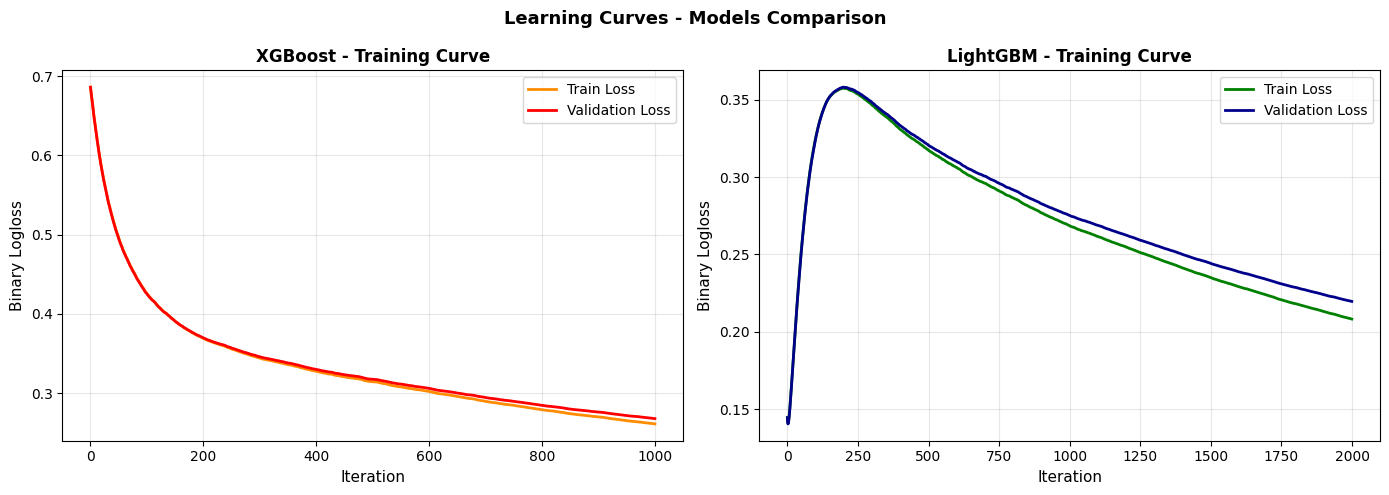

In [37]:
results_xgb = model_xgb.evals_result()
results_lgb = model_lgb.evals_result_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost - Training vs Validation Loss
axes[0].plot(results_xgb['validation_0']['logloss'], label='Train Loss', linewidth=2, color='darkorange')
axes[0].plot(results_xgb['validation_1']['logloss'], label='Validation Loss', linewidth=2, color='red')
axes[0].set_xlabel('Iteration', fontsize=11)
axes[0].set_ylabel('Binary Logloss', fontsize=11)
axes[0].set_title('XGBoost - Training Curve', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# LightGBM - Training vs Validation Loss
axes[1].plot(results_lgb['training']['binary_logloss'], label='Train Loss', linewidth=2, color='green')
axes[1].plot(results_lgb['valid_1']['binary_logloss'], label='Validation Loss', linewidth=2, color='darkblue')
axes[1].set_xlabel('Iteration', fontsize=11)
axes[1].set_ylabel('Binary Logloss', fontsize=11)
axes[1].set_title('LightGBM - Training Curve', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('Learning Curves - Models Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [38]:
y_test_pred = model_xgb.predict(x_test)
y_test_score = model_xgb.predict_proba(x_test)[:, 1]

print(f"classification_report: \n {classification_report(y_test, y_test_pred)}")
print(f"accuracy score: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"balanced accuracy score: {balanced_accuracy_score(y_test, y_test_pred):.4f}")
print(f"roc auc score: {roc_auc_score(y_test, y_test_score):.4f}")
cm_xgb = confusion_matrix(y_test, y_test_pred)

classification_report: 
               precision    recall  f1-score   support

           0       0.99      0.91      0.95     56988
           1       0.25      0.81      0.39      2066

    accuracy                           0.91     59054
   macro avg       0.62      0.86      0.67     59054
weighted avg       0.97      0.91      0.93     59054

accuracy score: 0.9102
balanced accuracy score: 0.8620
roc auc score: 0.9383


In [39]:
y_test_pred_lgb = model_lgb.predict(x_test)
y_test_score_lgb = model_lgb.predict_proba(x_test)[:, 1]

print(f"classification_report: \n {classification_report(y_test, y_test_pred_lgb)}")
print(f"accuracy score: {accuracy_score(y_test, y_test_pred_lgb):.4f}")
print(f"balanced accuracy score: {balanced_accuracy_score(y_test, y_test_pred_lgb):.4f}")
print(f"roc auc score: {roc_auc_score(y_test, y_test_score_lgb):.4f}")
cm_lgb = confusion_matrix(y_test, y_test_pred_lgb)

[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
classification_report: 
               precision    recall  f1-score   support

           0       0.99      0.93      0.96     56988
           1       0.31      0.81      0.45      2066

    accuracy                           0.93     59054
   macro avg       0.65      0.87      0.70     59054
weighted avg       0.97      0.93      0.94     59054

accuracy score: 0.9293
balanced accuracy score: 0.8740
roc auc score: 0.9485


In [40]:
preds_lgb = model_lgb.predict_proba(x_val)[:, 1]
preds_xgb = model_xgb.predict_proba(x_val)[:, 1]

X_meta_val = np.column_stack((preds_lgb, preds_xgb))

meta_learner = LogisticRegression(class_weight='balanced', random_state=42)
meta_learner.fit(X_meta_val, y_val)

print("Trọng số học được (Coefficients):")
print(f" - LightGBM: {meta_learner.coef_[0][0]:.4f}")
print(f" - XGBoost: {meta_learner.coef_[0][1]:.4f}")
print(f" - Bias (Intercept): {meta_learner.intercept_[0]:.4f}\n")

[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.


Trọng số học được (Coefficients):
 - LightGBM: 10.5355
 - XGBoost: -2.8475
 - Bias (Intercept): -3.3673



In [41]:
preds_lgb_test = model_lgb.predict_proba(x_test)[:, 1]
preds_xgb_test = model_xgb.predict_proba(x_test)[:, 1]

X_meta_test = np.column_stack((preds_lgb_test, preds_xgb_test))

meta_preds_proba_test = meta_learner.predict_proba(X_meta_test)[:, 1]
meta_preds_test = (meta_preds_proba_test >= 0.5).astype(int)

print(f"classification_report: \n {classification_report(y_test, meta_preds_test)}")
print(f"accuracy score: {accuracy_score(y_test, meta_preds_test):.4f}")
print(f"balanced accuracy score: {balanced_accuracy_score(y_test, meta_preds_test):.4f}")
print(f"roc auc score: {roc_auc_score(y_test, meta_preds_proba_test):.4f}")
cm = confusion_matrix(y_test, meta_preds_test)

[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
classification_report: 
               precision    recall  f1-score   support

           0       0.99      0.91      0.95     56988
           1       0.26      0.85      0.40      2066

    accuracy                           0.91     59054
   macro avg       0.63      0.88      0.68     59054
weighted avg       0.97      0.91      0.93     59054

accuracy score: 0.9108
balanced accuracy score: 0.8808
roc auc score: 0.9488


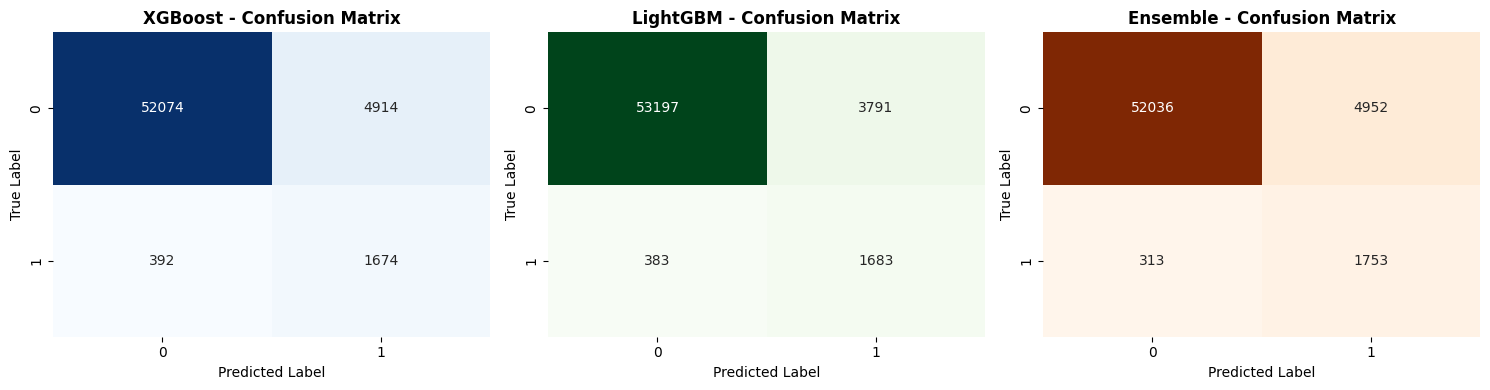

In [42]:
# Visualize confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot XGBoost confusion matrix
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('XGBoost - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot LightGBM confusion matrix
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('LightGBM - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

# Plot Ensemble (Meta-learner) confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[2], cbar=False)
axes[2].set_title('Ensemble - Confusion Matrix', fontsize=12, fontweight='bold')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

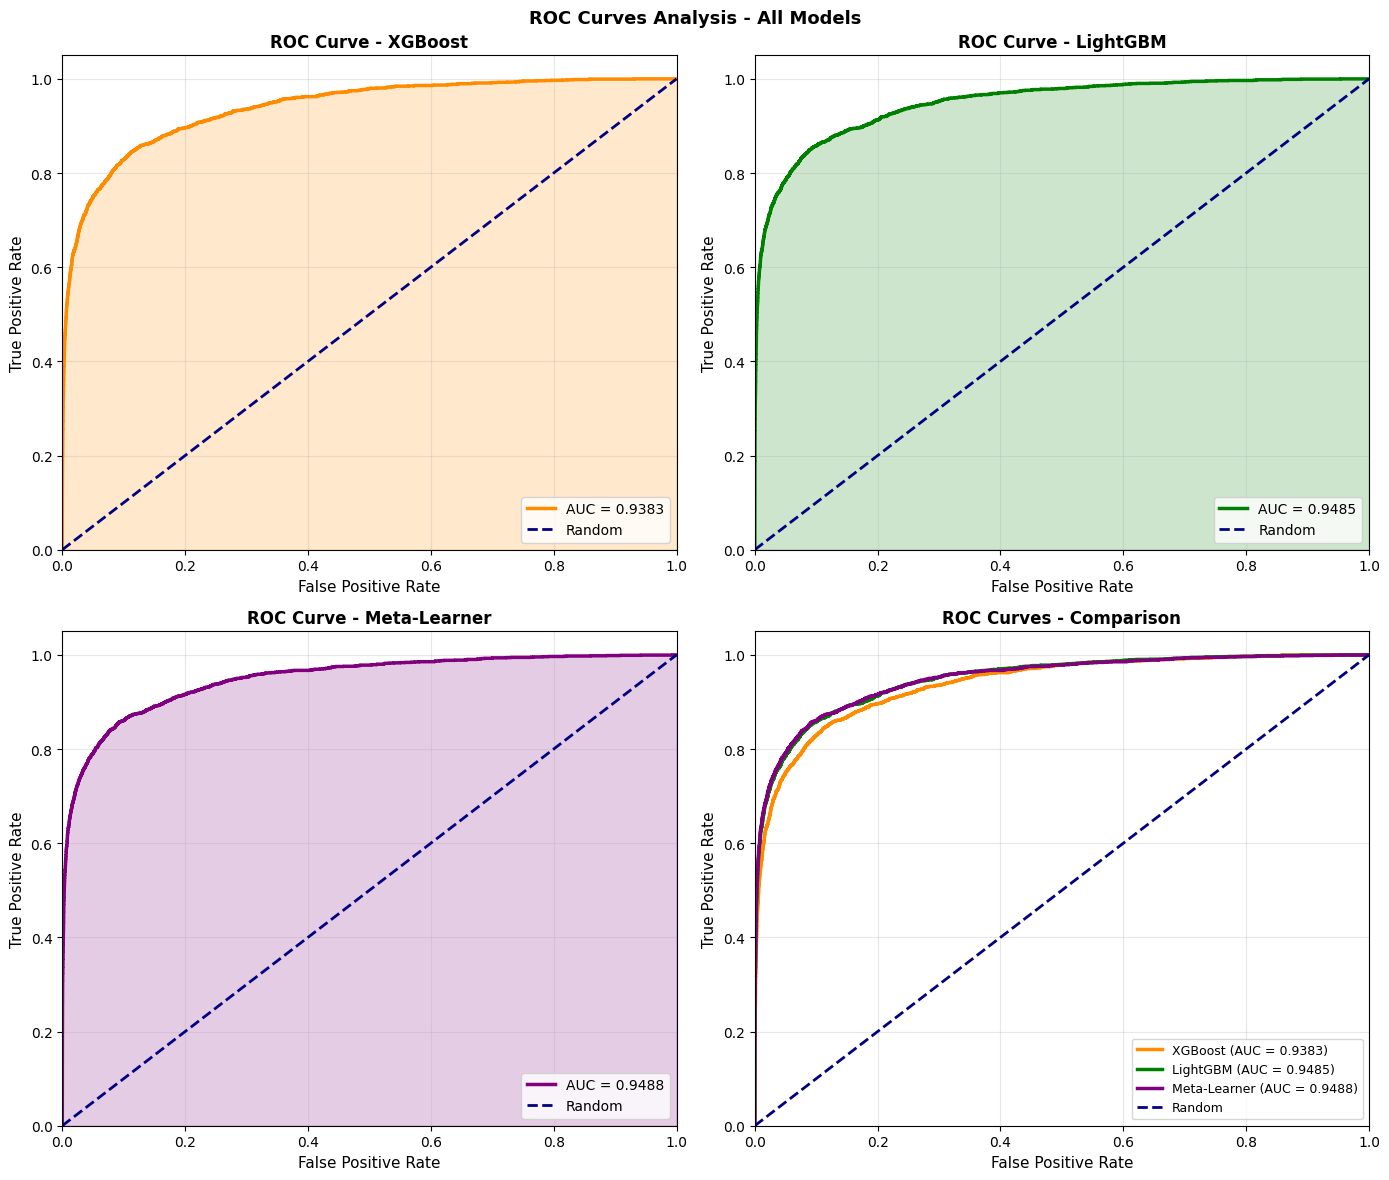

ROC-AUC SCORES SUMMARY
XGBoost        AUC: 0.938320
LightGBM       AUC: 0.948454
Meta-Learner   AUC: 0.948772


In [43]:
from sklearn.metrics import roc_curve, auc
# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, preds_xgb_test)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# LightGBM
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, preds_lgb_test)
auc_lgb = auc(fpr_lgb, tpr_lgb)

# Meta-Learner
fpr_meta, tpr_meta, _ = roc_curve(y_test, meta_preds_proba_test)
auc_meta = auc(fpr_meta, tpr_meta)

# === Vẽ ROC Curves - Layout 2x2 ===
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# XGBoost ROC
axes[0, 0].plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2.5, label=f'AUC = {auc_xgb:.4f}')
axes[0, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[0, 0].fill_between(fpr_xgb, tpr_xgb, alpha=0.2, color='darkorange')
axes[0, 0].set_xlim([0.0, 1.0])
axes[0, 0].set_ylim([0.0, 1.05])
axes[0, 0].set_xlabel('False Positive Rate', fontsize=11)
axes[0, 0].set_ylabel('True Positive Rate', fontsize=11)
axes[0, 0].set_title('ROC Curve - XGBoost', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc="lower right", fontsize=10)
axes[0, 0].grid(alpha=0.3)

# LightGBM ROC
axes[0, 1].plot(fpr_lgb, tpr_lgb, color='green', lw=2.5, label=f'AUC = {auc_lgb:.4f}')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[0, 1].fill_between(fpr_lgb, tpr_lgb, alpha=0.2, color='green')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate', fontsize=11)
axes[0, 1].set_ylabel('True Positive Rate', fontsize=11)
axes[0, 1].set_title('ROC Curve - LightGBM', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc="lower right", fontsize=10)
axes[0, 1].grid(alpha=0.3)

# Meta-Learner ROC
axes[1, 0].plot(fpr_meta, tpr_meta, color='purple', lw=2.5, label=f'AUC = {auc_meta:.4f}')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1, 0].fill_between(fpr_meta, tpr_meta, alpha=0.2, color='purple')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_xlabel('False Positive Rate', fontsize=11)
axes[1, 0].set_ylabel('True Positive Rate', fontsize=11)
axes[1, 0].set_title('ROC Curve - Meta-Learner', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc="lower right", fontsize=10)
axes[1, 0].grid(alpha=0.3)

# Comparison - Tất cả 3 models
axes[1, 1].plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2.5, label=f'XGBoost (AUC = {auc_xgb:.4f})')
axes[1, 1].plot(fpr_lgb, tpr_lgb, color='green', lw=2.5, label=f'LightGBM (AUC = {auc_lgb:.4f})')
axes[1, 1].plot(fpr_meta, tpr_meta, color='purple', lw=2.5, label=f'Meta-Learner (AUC = {auc_meta:.4f})')
axes[1, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1, 1].set_xlim([0.0, 1.0])
axes[1, 1].set_ylim([0.0, 1.05])
axes[1, 1].set_xlabel('False Positive Rate', fontsize=11)
axes[1, 1].set_ylabel('True Positive Rate', fontsize=11)
axes[1, 1].set_title('ROC Curves - Comparison', fontsize=12, fontweight='bold')
axes[1, 1].legend(loc="lower right", fontsize=9)
axes[1, 1].grid(alpha=0.3)

plt.suptitle('ROC Curves Analysis - All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("ROC-AUC SCORES SUMMARY")
print(f"XGBoost        AUC: {auc_xgb:.6f}")
print(f"LightGBM       AUC: {auc_lgb:.6f}")
print(f"Meta-Learner   AUC: {auc_meta:.6f}")
